In [2]:
import numpy as np
import pandas as pd
from scipy.stats import rankdata, norm
from scipy.stats import t as tdist
from scipy.optimize import minimize_scalar, minimize
from scipy.special import gammaln
from scipy.ndimage import uniform_filter1d

# ── 1. Data loading ───────────────────────────────────────────────
def load_close(path):
    s = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["Close"]
    s.index = pd.to_datetime(s.index, format="%d.%m.%Y")
    return s

def std_log_returns(s):
    lr = np.log(s / s.shift(1)).dropna()
    return (lr - lr.mean()) / lr.std()

def align(s1, s2):
    idx = s1.index.intersection(s2.index)
    return s1.loc[idx].values, s2.loc[idx].values

def fit_t_margin(z):
    res = minimize(lambda p: -np.sum(tdist.logpdf(z, df=p[0], loc=p[1], scale=p[2])),
                   x0=[4, 0, 1], bounds=[(2, 30), (-1, 1), (0.1, 5)])
    df, loc, scale = res.x
    return tdist.cdf(z, df=df, loc=loc, scale=scale)

def ll_gauss(rho, u, v):
    x_ = norm.ppf(u); y_ = norm.ppf(v); r2 = rho**2
    return np.sum(-0.5*np.log(1-r2) - (r2*(x_**2+y_**2) - 2*rho*x_*y_)/(2*(1-r2)))

def ll_t(rho, nu, u, v):
    x_ = tdist.ppf(u, df=nu); y_ = tdist.ppf(v, df=nu); r2 = rho**2
    return np.sum(gammaln((nu+2)/2) + gammaln(nu/2) - 2*gammaln((nu+1)/2)
                  - 0.5*np.log(1-r2)
                  - ((nu+2)/2)*np.log(1+(x_**2+y_**2-2*rho*x_*y_)/(nu*(1-r2)))
                  + ((nu+1)/2)*(np.log(1+x_**2/nu)+np.log(1+y_**2/nu)))

def ll_gumbel(theta, u, v):
    if theta < 1: return -np.inf
    lu = -np.log(u); lv = -np.log(v)
    A  = (lu**theta + lv**theta)**(1/theta)
    return np.sum(-A + np.log(1/u) + np.log(1/v)
                  + (1/theta-2)*np.log(lu**theta+lv**theta)
                  + np.log(A+theta-1) + (theta-1)*(np.log(lu)+np.log(lv)))

def ll_clayton(theta, u, v):
    if theta <= 0: return -np.inf
    return np.sum(np.log(1+theta) - (1+theta)*(np.log(u)+np.log(v))
                  - (2+1/theta)*np.log(u**(-theta)+v**(-theta)-1))

def ll_frank(theta, u, v):
    if abs(theta) < 1e-6: return -np.inf
    num = -theta*(1-np.exp(-theta))*np.exp(-theta*(u+v))
    den = ((1-np.exp(-theta))-(1-np.exp(-theta*u))*(1-np.exp(-theta*v)))**2
    return np.sum(np.log(np.maximum(num/den, 1e-300)))

def tdc_t(rho, nu):
    return 2 * tdist.sf(np.sqrt((nu+1)*(1-rho)/(1+rho)), df=nu+1)

def msrnonp(a, b, lower=False, bw=20):
    if lower: a, b = -a, -b
    T  = len(a); s1 = rankdata(a); s2 = rankdata(b)
    lam = np.array([np.sum((s1>(T-k))&(s2>(T-k)))/k for k in range(1,T)])
    xs  = uniform_filter1d(lam, size=bw, mode="nearest")
    n   = len(xs); bv = int(np.floor(0.005*n)); m = int(np.floor(np.sqrt(n-2*bv)))
    sd  = np.std(xs[:n-2*bv], ddof=1)
    k_star = 0
    for k in range(n-m-2*bv+1):
        if np.sum(np.abs(xs[k+1:k+m]-xs[k])) <= sd:
            k_star = k; break
    return float(np.mean(xs[k_star:k_star+m]))

def copula_tdc_table(x, y, pair_name, nu_t=4, nu_tcdf=5):
    eps = 1e-6
    u = np.clip(fit_t_margin(x), eps, 1-eps)
    v = np.clip(fit_t_margin(y), eps, 1-eps)

    rho_g  = minimize_scalar(lambda r: -ll_gauss(r, u, v),   bounds=(-0.99,0.99), method="bounded").x
    rho_t  = minimize_scalar(lambda r: -ll_t(r, nu_t, u, v), bounds=(-0.99,0.99), method="bounded").x
    th_gum = minimize_scalar(lambda t: -ll_gumbel(t, u, v),  bounds=(1.0, 10.0),  method="bounded").x
    th_cla = minimize_scalar(lambda t: -ll_clayton(t, u, v), bounds=(0.01,10.0),  method="bounded").x
    th_fra = minimize_scalar(lambda t: -ll_frank(t, u, v),   bounds=(0.01,20.0),  method="bounded").x

    np_up    = msrnonp(x, y, lower=False)
    np_lo    = msrnonp(x, y, lower=True)
    tcdf_tdc = tdc_t(rho_g, nu_tcdf)

    table = pd.DataFrame({
        "Copula":     ["Gauss", f"t({nu_t})", "Gumbel", "Clayton", "Frank",
                       "Nonparametric", f"bivariate t-cdf"],
        "Parameters": [f"{rho_g:.4f}", f"{rho_t:.4f}", f"{th_gum:.4f}",
                       f"{th_cla:.4f}", f"{th_fra:.4f}", "—", str(nu_tcdf)],
        "Upper TDC":  [0, round(tdc_t(rho_t, nu_t), 4),
                       round(2 - 2**(1/th_gum), 4), 0, 0,
                       round(np_up, 4), round(tcdf_tdc, 4)],
        "Lower TDC":  [0, round(tdc_t(rho_t, nu_t), 4),
                       0, round(2**(-1/th_cla), 4), 0,
                       round(np_lo, 4), round(tcdf_tdc, 4)],
    })

    print(f"\n{'='*60}")
    print(f"  TDC Table — {pair_name}")
    print(f"{'='*60}")
    print(table.to_string(index=False))
    return table

# ── Run for BMW & Volkswagen only ─────────────────────────────────
r_bmw = std_log_returns(load_close("../Data/BMW_DE_price_volume.csv"))
r_vow = std_log_returns(load_close("../Data/VOW_DE_price_volume.csv"))

x_bmw, x_vow = align(r_bmw, r_vow)
table_bmw_vow = copula_tdc_table(x_bmw, x_vow, "BMW & Volkswagen")


  TDC Table — BMW & Volkswagen
         Copula Parameters  Upper TDC  Lower TDC
          Gauss     0.6145     0.0000     0.0000
           t(4)     0.6646     0.3616     0.3616
         Gumbel     1.7530     0.5150     0.0000
        Clayton     1.1957     0.0000     0.5601
          Frank    20.0000     0.0000     0.0000
  Nonparametric          —     0.3157     0.4815
bivariate t-cdf          5     0.2765     0.2765


In [6]:
# ── F. Run BMW-VOW only ───────────────────────────────────────────

COPULAS  = ["Gauss", "t", "Gumbel", "Clayton", "Frank"]
WINDOW   = 250
LEVEL    = 0.05
N_SIM    = 10_000
W        = (1, 1)
NU_T     = 4

# x_bmw, x_vow already defined from the TDC section above
PAIRS = {
    "BMW-VOW": (x_bmw, x_vow),
}

all_results = {}

for pair_name, (xa, ya) in PAIRS.items():
    print(f"\n{'═'*60}")
    print(f"  Pair: {pair_name}   (n = {len(xa)} obs)")
    print(f"{'═'*60}")

    params = fit_all_copulas(xa, ya, nu_t=NU_T)
    vr = {}

    for cop in COPULAS:
        print(f"  [{cop:8s}] running backtest ...", end=" ", flush=True)
        vr[cop] = backtest_var(xa, ya, params[cop], cop,
                               window=WINDOW, level=LEVEL,
                               n_sim=N_SIM, w=W)
        print(f"violation rate = {vr[cop]:.4f}")

    vr["Normal"] = backtest_normal(xa, ya, window=WINDOW,
                                   level=LEVEL, w=W)
    print(f"  [Normal  ] violation rate = {vr['Normal']:.4f}")
    all_results[pair_name] = vr


# ── G. Print Table ────────────────────────────────────────────────

pairs_list = list(all_results.keys())
col_w, name_w = 14, 22

header  = f"{'Copula':<{name_w}}" + "".join(f"{p:>{col_w}}" for p in pairs_list)
divider = "─" * len(header)

print(f"\n\nVaR Backtesting — BMW-VOW (violation rates, target = {LEVEL})")
print(f"Window = {WINDOW}  |  MC = {N_SIM}  |  w = (1,1)ᵀ  |  t({NU_T}) copula")
print(divider)
print(header)
print(divider)
for cop in COPULAS:
    row = f"{cop:<{name_w}}"
    for p in pairs_list:
        row += f"{all_results[p][cop]:>{col_w}.4f}"
    print(row)
print(divider)
norm_row = f"{'Normal distribution':<{name_w}}"
for p in pairs_list:
    norm_row += f"{all_results[p]['Normal']:>{col_w}.4f}"
print(norm_row)
print(divider)


════════════════════════════════════════════════════════════
  Pair: BMW-VOW   (n = 7105 obs)
════════════════════════════════════════════════════════════
  [Gauss   ] running backtest ... violation rate = 0.0586
violation rate = 0.0579cktest ... 
violation rate = 0.0629cktest ... 
violation rate = 0.0093cktest ... 
violation rate = 0.0452cktest ... 
  [Normal  ] violation rate = 0.0540


VaR Backtesting — BMW-VOW (violation rates, target = 0.05)
Window = 250  |  MC = 10000  |  w = (1,1)ᵀ  |  t(4) copula
────────────────────────────────────
Copula                       BMW-VOW
────────────────────────────────────
Gauss                         0.0586
t                             0.0579
Gumbel                        0.0629
Clayton                       0.0093
Frank                         0.0452
────────────────────────────────────
Normal distribution           0.0540
────────────────────────────────────



Gumbel alpha_hat = 0.0635
Normal alpha_hat = 0.0540


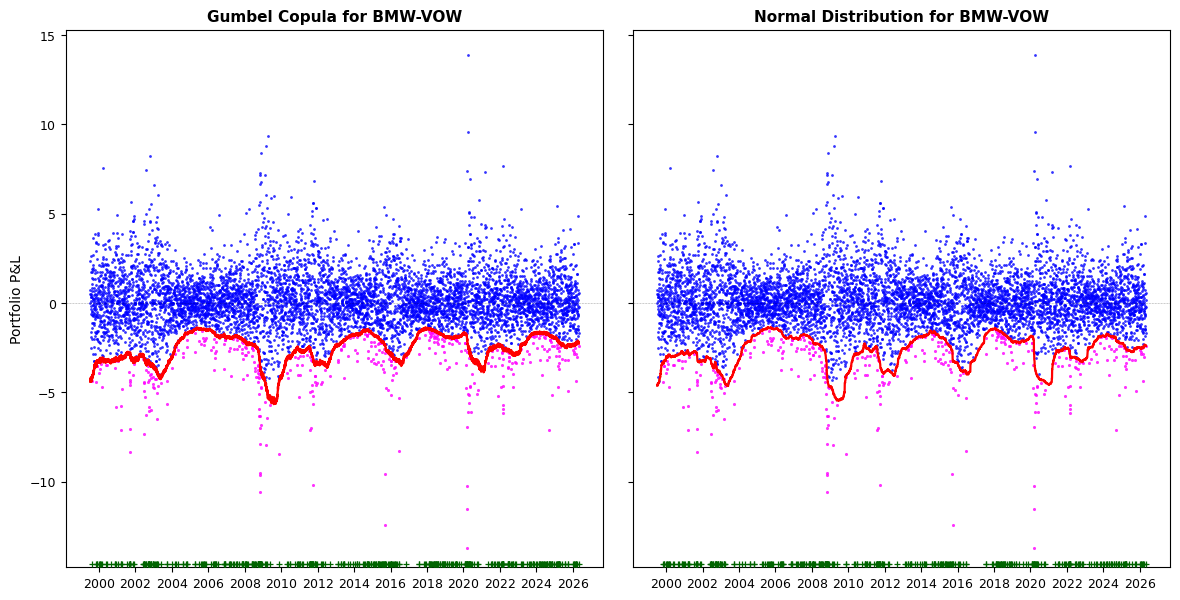

In [12]:
# ── H. Extra functions needed for charts ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy import stats

def fit_t_window(z):
    """
    Re-fit t margin on a rolling window.
    Returns (scale, df).
    """
    res = minimize(
        lambda p: -np.sum(tdist.logpdf(z, df=p[0], loc=p[1], scale=p[2])),
        x0=[4, 0, 1],
        bounds=[(2, 30), (-1, 1), (0.1, 5)],
        method="L-BFGS-B"
    )
    df, loc, scale = res.x
    return float(scale), float(df)

def sample_gauss(rho, n):
    z = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    return norm.cdf(z[:, 0]), norm.cdf(z[:, 1])

def sample_t(rho, nu, n):
    z = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    chi2 = np.random.chisquare(nu, n)
    td = z / np.sqrt(chi2[:, None] / nu)
    return tdist.cdf(td[:, 0], df=nu), tdist.cdf(td[:, 1], df=nu)

def sample_gumbel(theta, n):
    eps = 1e-9
    V = stats.levy_stable.rvs(
        1/theta, 1, size=n,
        scale=(np.cos(np.pi/(2*theta)))**theta
    )
    E1 = np.random.exponential(1, n)
    E2 = np.random.exponential(1, n)
    u = np.clip(np.exp(-((E1 / V)**(1/theta))), eps, 1 - eps)
    v = np.clip(np.exp(-((E2 / V)**(1/theta))), eps, 1 - eps)
    return u, v

def sample_clayton(theta, n):
    eps = 1e-9
    u = np.random.uniform(0, 1, n)
    p = np.random.uniform(0, 1, n)
    v = u * (p**(-theta/(1+theta)) - 1 + u**(-theta))**(-1/theta)
    return np.clip(u, eps, 1-eps), np.clip(v, eps, 1-eps)

def sample_frank(theta, n):
    eps = 1e-9
    u = np.random.uniform(0, 1, n)
    p = np.random.uniform(0, 1, n)
    et = np.exp(-theta)
    etu = np.exp(-theta * u)
    v = -1/theta * np.log(1 + p*(et - 1) / (etu - p*(etu - 1)))
    return np.clip(u, eps, 1-eps), np.clip(v, eps, 1-eps)

def mc_var(sampler_fn, sig1, sig2, df1, df2,
           n_sim=10_000, level=0.05, w=(1, 1)):
    """
    Monte Carlo VaR with t-margins.
    Returns VaR as positive loss.
    """
    us, vs = sampler_fn(n_sim)
    r1 = tdist.ppf(np.clip(us, 1e-9, 1-1e-9), df=df1) * sig1
    r2 = tdist.ppf(np.clip(vs, 1e-9, 1-1e-9), df=df2) * sig2
    pnl = w[0] * r1 + w[1] * r2
    return float(-np.quantile(pnl, level))

def fit_all_copulas(x, y, nu_t=4, eps=1e-6):
    u = np.clip(fit_t_margin(x), eps, 1-eps)
    v = np.clip(fit_t_margin(y), eps, 1-eps)

    rho_g  = minimize_scalar(lambda r: -ll_gauss(r, u, v),
                             bounds=(-0.99, 0.99), method="bounded").x
    rho_t  = minimize_scalar(lambda r: -ll_t(r, nu_t, u, v),
                             bounds=(-0.99, 0.99), method="bounded").x
    th_gum = minimize_scalar(lambda t: -ll_gumbel(t, u, v),
                             bounds=(1.0, 10.0), method="bounded").x
    th_cla = minimize_scalar(lambda t: -ll_clayton(t, u, v),
                             bounds=(0.01, 10.0), method="bounded").x
    th_fra = minimize_scalar(lambda t: -ll_frank(t, u, v),
                             bounds=(0.01, 20.0), method="bounded").x

    return {
        "Gauss":   {"rho": float(rho_g)},
        "t":       {"rho": float(rho_t), "nu": nu_t},
        "Gumbel":  {"theta": float(th_gum)},
        "Clayton": {"theta": float(th_cla)},
        "Frank":   {"theta": float(th_fra)},
    }

# ── I. Backtests that store full time series ──────────────────────
def backtest_var_series(x_all, y_all, dates, copula_params, family,
                        window=250, level=0.05, n_sim=10_000, w=(1, 1)):
    SAMPLERS = {
        "Gauss":   lambda p, n: sample_gauss(p["rho"], n),
        "t":       lambda p, n: sample_t(p["rho"], p["nu"], n),
        "Gumbel":  lambda p, n: sample_gumbel(p["theta"], n),
        "Clayton": lambda p, n: sample_clayton(p["theta"], n),
        "Frank":   lambda p, n: sample_frank(p["theta"], n),
    }
    sampler = SAMPLERS[family]

    T = len(x_all)
    out_dates, pnl_list, var_list = [], [], []

    for t in range(window, T):
        wx, wy = x_all[t-window:t], y_all[t-window:t]

        try:
            sig1, df1 = fit_t_window(wx)
            sig2, df2 = fit_t_window(wy)
        except Exception:
            continue

        fn = lambda n: sampler(copula_params, n)
        var_hat = mc_var(fn, sig1, sig2, df1, df2,
                         n_sim=n_sim, level=level, w=w)
        realized = w[0] * x_all[t] + w[1] * y_all[t]

        out_dates.append(dates[t])
        pnl_list.append(realized)
        var_list.append(var_hat)

    pnl = np.array(pnl_list)
    var_series = np.array(var_list)
    exceed = pnl < -var_series

    return np.array(out_dates), pnl, var_series, exceed

def backtest_normal_series(x_all, y_all, dates, window=250, level=0.05, w=(1, 1)):
    T = len(x_all)
    out_dates, pnl_list, var_list = [], [], []

    for t in range(window, T):
        port = w[0] * x_all[t-window:t] + w[1] * y_all[t-window:t]
        mu, sig = np.mean(port), np.std(port, ddof=1)
        var_hat = -(mu + norm.ppf(level) * sig)
        realized = w[0] * x_all[t] + w[1] * y_all[t]

        out_dates.append(dates[t])
        pnl_list.append(realized)
        var_list.append(var_hat)

    pnl = np.array(pnl_list)
    var_series = np.array(var_list)
    exceed = pnl < -var_series

    return np.array(out_dates), pnl, var_series, exceed

# ── J. Plot Figure 41 style ───────────────────────────────────────
def plot_var_panels(left_data, right_data,
                    left_title, right_title,
                    alpha_left, alpha_right,
                    save_path="fig41_bmw_vow.pdf"):

    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)  # (1)
    fig.patch.set_alpha(0)                                          # transparent figure bg
    fig.subplots_adjust(wspace=0.06)

    panel_data   = [left_data,   right_data  ]
    panel_titles = [left_title,  right_title ]
    alphas       = [alpha_left,  alpha_right ]

    for ax, (dates, pnl, var_s, exceed), title, a_hat in zip(
        axes, panel_data, panel_titles, alphas
    ):
        ax.patch.set_alpha(0)                                       # transparent axes bg

        y_bottom = min(pnl.min(), (-var_s).min()) - 0.9

        ax.scatter(
            dates[~exceed], pnl[~exceed],
            c="blue", s=4, alpha=0.8, linewidths=0,
            label="Profit/Loss", zorder=2
        )

        if exceed.any():
            ax.scatter(
                dates[exceed], pnl[exceed],
                c="magenta", s=5, alpha=0.8, linewidths=0,
                label="Exceedances", zorder=3
            )

        ax.plot(
            dates, -var_s,
            color="red", linewidth=1.6,
            label="VaR", zorder=4
        )

        if exceed.any():
            ax.scatter(
                dates[exceed],
                np.full(exceed.sum(), y_bottom),
                marker="+", c="darkgreen", s=24,
                linewidths=0.9, zorder=5
            )

        ax.axhline(0, color="black", linewidth=0.4, linestyle="--", alpha=0.35)
        ax.set_title(title, fontsize=11, fontweight="bold")

        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))    # (2) year only

        ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.set_ylim(bottom=y_bottom - 0.2)

        ax.set_box_aspect(1)                                        # (3) square panel

        # ax.text(
        #     0.02, 0.04, f"$\\hat{{\\alpha}}$ = {a_hat:.4f}",
        #     transform=ax.transAxes, fontsize=9,
        #     color="dimgray", va="bottom"
        # )

    axes[0].set_ylabel("Portfolio P&L", fontsize=10)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight",
                transparent=True)                                    # (1) transparent save
    plt.show()

# ── K. Build BMW-VOW Figure 41 ────────────────────────────────────
# Re-fit copulas here so this block is self-contained
params = fit_all_copulas(x_bmw, x_vow, nu_t=NU_T)

idx_bv = r_bmw.index.intersection(r_vow.index)
dates_bv = idx_bv.to_numpy()

gumbel_series = backtest_var_series(
    x_bmw, x_vow, dates_bv,
    params["Gumbel"], "Gumbel",
    window=WINDOW, level=LEVEL, n_sim=N_SIM, w=W
)
normal_series = backtest_normal_series(
    x_bmw, x_vow, dates_bv,
    window=WINDOW, level=LEVEL, w=W
)

alpha_gum = float(gumbel_series[3].mean())
alpha_norm = float(normal_series[3].mean())

print(f"\nGumbel alpha_hat = {alpha_gum:.4f}")
print(f"Normal alpha_hat = {alpha_norm:.4f}")

plot_var_panels(
    left_data=gumbel_series,
    right_data=normal_series,
    left_title="Gumbel Copula for BMW-VOW",
    right_title="Normal Distribution for BMW-VOW",
    alpha_left=alpha_gum,
    alpha_right=alpha_norm,
    save_path="fig41_bmw_vow.pdf"
)

**Cell 1 — Imports and configuration**

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker
from scipy import stats
from scipy.stats import rankdata, norm, t as tdist
from scipy.optimize import minimize_scalar, minimize
from scipy.special import gammaln
from scipy.ndimage import uniform_filter1d

DATA_DIR = "../Data"
OUTPUT_DIR = os.getcwd()

EPS = 1e-6
NU_T = 4
NU_TCDF = 5
WINDOW = 250
LEVEL = 0.05
N_SIM = 10_000
W = (1, 1)
COPULAS = ["Gauss", "t", "Gumbel", "Clayton", "Frank"]

**Cell 2 — Data loading and margin fitting**

In [2]:
def load_close(filename):
    path = os.path.join(DATA_DIR, filename)
    s = pd.read_csv(path, parse_dates=["Date"]).set_index("Date")["Close"]
    s.index = pd.to_datetime(s.index, format="%d.%m.%Y")
    return s

def std_log_returns(s):
    lr = np.log(s / s.shift(1)).dropna()
    return (lr - lr.mean()) / lr.std()

def align(s1, s2):
    idx = s1.index.intersection(s2.index)
    return s1.loc[idx].values, s2.loc[idx].values

def fit_t_margin(z, return_params=False):
    """Fit t-distribution to z via MLE. Returns u=F_t(z), and optionally (sigma, df)."""
    res = minimize(
        lambda p: -np.sum(tdist.logpdf(z, df=p[0], loc=p[1], scale=p[2])),
        x0=[4, 0, 1], bounds=[(2, 30), (-1, 1), (0.1, 5)], method="L-BFGS-B",
    )
    df, loc, scale = res.x
    u = tdist.cdf(z, df=df, loc=loc, scale=scale)
    return (u, float(scale), float(df)) if return_params else u

**Cell 3 — Copula log-likelihoods and TDC formulas**

In [4]:
def ll_gauss(rho, u, v):
    x_, y_ = norm.ppf(u), norm.ppf(v)
    r2 = rho ** 2
    return np.sum(-0.5 * np.log(1 - r2) - (r2 * (x_**2 + y_**2) - 2 * rho * x_ * y_) / (2 * (1 - r2)))

def ll_t(rho, nu, u, v):
    x_, y_ = tdist.ppf(u, df=nu), tdist.ppf(v, df=nu)
    r2 = rho ** 2
    return np.sum(gammaln((nu + 2) / 2) + gammaln(nu / 2) - 2 * gammaln((nu + 1) / 2)
                  - 0.5 * np.log(1 - r2)
                  - ((nu + 2) / 2) * np.log(1 + (x_**2 + y_**2 - 2 * rho * x_ * y_) / (nu * (1 - r2)))
                  + ((nu + 1) / 2) * (np.log(1 + x_**2 / nu) + np.log(1 + y_**2 / nu)))

def ll_gumbel(theta, u, v):
    if theta < 1:
        return -np.inf
    lu, lv = -np.log(u), -np.log(v)
    A = (lu**theta + lv**theta) ** (1 / theta)
    return np.sum(-A + np.log(1 / u) + np.log(1 / v)
                  + (1 / theta - 2) * np.log(lu**theta + lv**theta)
                  + np.log(A + theta - 1) + (theta - 1) * (np.log(lu) + np.log(lv)))

def ll_clayton(theta, u, v):
    if theta <= 0:
        return -np.inf
    return np.sum(np.log(1 + theta) - (1 + theta) * (np.log(u) + np.log(v))
                  - (2 + 1 / theta) * np.log(u**(-theta) + v**(-theta) - 1))

def ll_frank(theta, u, v):
    if abs(theta) < 1e-6:
        return -np.inf
    num = -theta * (1 - np.exp(-theta)) * np.exp(-theta * (u + v))
    den = ((1 - np.exp(-theta)) - (1 - np.exp(-theta * u)) * (1 - np.exp(-theta * v))) ** 2
    return np.sum(np.log(np.maximum(num / den, 1e-300)))

def tdc_t(rho, nu):
    return 2 * tdist.sf(np.sqrt((nu + 1) * (1 - rho) / (1 + rho)), df=nu + 1)

def tdc_gumbel_upper(theta):
    return 2 - 2 ** (1 / theta)

def tdc_clayton_lower(theta):
    return 2 ** (-1 / theta)

def msrnonp(a, b, lower=False, bw=20):
    if lower:
        a, b = -a, -b
    T = len(a)
    s1, s2 = rankdata(a), rankdata(b)
    lam = np.array([np.sum((s1 > (T - k)) & (s2 > (T - k))) / k for k in range(1, T)])
    xs = uniform_filter1d(lam, size=bw, mode="nearest")

    n = len(xs)
    bv = int(np.floor(0.005 * n))
    m = int(np.floor(np.sqrt(n - 2 * bv)))
    sd = np.std(xs[:n - 2 * bv], ddof=1)

    k_star = 0
    for k in range(n - m - 2 * bv + 1):
        if np.sum(np.abs(xs[k + 1:k + m] - xs[k])) <= sd:
            k_star = k
            break
    return float(np.mean(xs[k_star:k_star + m]))

**Cell 4 — Single copula-fitting function (replaces both duplicates)**

In [5]:
def fit_all_copulas(x, y, nu_t=NU_T, eps=EPS):
    """Fit all five copula families via MLE. Single source of truth for params."""
    u = np.clip(fit_t_margin(x), eps, 1 - eps)
    v = np.clip(fit_t_margin(y), eps, 1 - eps)

    rho_g = minimize_scalar(lambda r: -ll_gauss(r, u, v), bounds=(-0.99, 0.99), method="bounded").x
    rho_t = minimize_scalar(lambda r: -ll_t(r, nu_t, u, v), bounds=(-0.99, 0.99), method="bounded").x
    th_gum = minimize_scalar(lambda t: -ll_gumbel(t, u, v), bounds=(1.0, 10.0), method="bounded").x
    th_cla = minimize_scalar(lambda t: -ll_clayton(t, u, v), bounds=(0.01, 10.0), method="bounded").x
    th_fra = minimize_scalar(lambda t: -ll_frank(t, u, v), bounds=(0.01, 20.0), method="bounded").x

    return {
        "Gauss":   {"rho": float(rho_g)},
        "t":       {"rho": float(rho_t), "nu": nu_t},
        "Gumbel":  {"theta": float(th_gum)},
        "Clayton": {"theta": float(th_cla)},
        "Frank":   {"theta": float(th_fra)},
    }

def copula_tdc_table(x, y, pair_name, params, nu_tcdf=NU_TCDF):
    """Build the TDC summary table from already-fitted copula params."""
    rho_g = params["Gauss"]["rho"]
    rho_t, nu_t = params["t"]["rho"], params["t"]["nu"]
    th_gum, th_cla = params["Gumbel"]["theta"], params["Clayton"]["theta"]

    np_up = msrnonp(x, y, lower=False)
    np_lo = msrnonp(x, y, lower=True)
    tcdf_tdc = tdc_t(rho_g, nu_tcdf)

    table = pd.DataFrame({
        "Copula": ["Gauss", f"t({nu_t})", "Gumbel", "Clayton", "Frank", "Nonparametric", "bivariate t-cdf"],
        "Parameters": [
            f"{rho_g:.4f}", f"{rho_t:.4f}", f"{th_gum:.4f}",
            f"{th_cla:.4f}", f"{params['Frank']['theta']:.4f}", "-", str(nu_tcdf),
        ],
        "Upper TDC": [0, round(tdc_t(rho_t, nu_t), 4), round(tdc_gumbel_upper(th_gum), 4),
                      0, 0, round(np_up, 4), round(tcdf_tdc, 4)],
        "Lower TDC": [0, round(tdc_t(rho_t, nu_t), 4), 0,
                      round(tdc_clayton_lower(th_cla), 4), 0, round(np_lo, 4), round(tcdf_tdc, 4)],
    })

    print(f"\n{'=' * 60}\n  TDC Table - {pair_name}\n{'=' * 60}")
    print(table.to_string(index=False))
    return table

**Cell 5 — Load BMW/VOW and run TDC table**

In [6]:
r_bmw = std_log_returns(load_close("BMW_DE_price_volume.csv"))
r_vow = std_log_returns(load_close("VOW_DE_price_volume.csv"))
x_bmw, x_vow = align(r_bmw, r_vow)

dates_bv = r_bmw.index.intersection(r_vow.index).to_numpy()

copula_params = fit_all_copulas(x_bmw, x_vow, nu_t=NU_T)
table_bmw_vow = copula_tdc_table(x_bmw, x_vow, "BMW & Volkswagen", copula_params)


  TDC Table - BMW & Volkswagen
         Copula Parameters  Upper TDC  Lower TDC
          Gauss     0.6145     0.0000     0.0000
           t(4)     0.6646     0.3616     0.3616
         Gumbel     1.7530     0.5150     0.0000
        Clayton     1.1957     0.0000     0.5601
          Frank    20.0000     0.0000     0.0000
  Nonparametric          -     0.3157     0.4815
bivariate t-cdf          5     0.2765     0.2765


**Cell 6 — Copula samplers and Monte Carlo VaR (single definitions)**

In [7]:
def _clip_uv(u, v, eps=1e-9):
    return np.clip(u, eps, 1 - eps), np.clip(v, eps, 1 - eps)

def sample_gauss(rho, n):
    z = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    return norm.cdf(z[:, 0]), norm.cdf(z[:, 1])

def sample_t(rho, nu, n):
    z = np.random.multivariate_normal([0, 0], [[1, rho], [rho, 1]], n)
    chi2 = np.random.chisquare(nu, n)
    td = z / np.sqrt(chi2[:, None] / nu)
    return tdist.cdf(td[:, 0], df=nu), tdist.cdf(td[:, 1], df=nu)

def sample_gumbel(theta, n):
    Vv = stats.levy_stable.rvs(1 / theta, 1, size=n, scale=(np.cos(np.pi / (2 * theta))) ** theta)
    E1, E2 = np.random.exponential(1, n), np.random.exponential(1, n)
    u = np.exp(-((E1 / Vv) ** (1 / theta)))
    v = np.exp(-((E2 / Vv) ** (1 / theta)))
    return _clip_uv(u, v)

def sample_clayton(theta, n):
    u = np.random.uniform(0, 1, n)
    p = np.random.uniform(0, 1, n)
    v = u * (p ** (-theta / (1 + theta)) - 1 + u ** (-theta)) ** (-1 / theta)
    return _clip_uv(u, v)

def sample_frank(theta, n):
    u = np.random.uniform(0, 1, n)
    p = np.random.uniform(0, 1, n)
    et = np.exp(-theta)
    etu = np.exp(-theta * u)
    v = -1 / theta * np.log(1 + p * (et - 1) / (etu - p * (etu - 1)))
    return _clip_uv(u, v)

SAMPLERS = {
    "Gauss":   lambda p, n: sample_gauss(p["rho"], n),
    "t":       lambda p, n: sample_t(p["rho"], p["nu"], n),
    "Gumbel":  lambda p, n: sample_gumbel(p["theta"], n),
    "Clayton": lambda p, n: sample_clayton(p["theta"], n),
    "Frank":   lambda p, n: sample_frank(p["theta"], n),
}

def mc_var(sampler_fn, sig1, sig2, df1, df2, n_sim=N_SIM, level=LEVEL, w=W):
    us, vs = sampler_fn(n_sim)
    r1 = tdist.ppf(np.clip(us, 1e-9, 1 - 1e-9), df=df1) * sig1
    r2 = tdist.ppf(np.clip(vs, 1e-9, 1 - 1e-9), df=df2) * sig2
    pnl = w[0] * r1 + w[1] * r2
    return float(-np.quantile(pnl, level))

**Cell 7 — Rolling backtest functions (both scalar-rate and full-series versions)**

In [8]:
def backtest_var(x_all, y_all, params, family, window=WINDOW, level=LEVEL, n_sim=N_SIM, w=W):
    """Rolling backtest returning only the violation rate."""
    sampler = SAMPLERS[family]
    T = len(x_all)
    violations, total = 0, 0

    for t in range(window, T):
        wx, wy = x_all[t - window:t], y_all[t - window:t]
        try:
            _, sig1, df1 = fit_t_margin(wx, return_params=True)
            _, sig2, df2 = fit_t_margin(wy, return_params=True)
        except Exception:
            continue

        var_hat = mc_var(lambda n: sampler(params, n), sig1, sig2, df1, df2, n_sim=n_sim, level=level, w=w)
        realized = w[0] * x_all[t] + w[1] * y_all[t]
        violations += int(realized < -var_hat)
        total += 1

    return violations / total if total > 0 else float("nan")

def backtest_normal(x_all, y_all, window=WINDOW, level=LEVEL, w=W):
    T = len(x_all)
    violations, total = 0, 0
    for t in range(window, T):
        port = w[0] * x_all[t - window:t] + w[1] * y_all[t - window:t]
        mu, sig = np.mean(port), np.std(port, ddof=1)
        var_hat = -(mu + norm.ppf(level) * sig)
        violations += int(w[0] * x_all[t] + w[1] * y_all[t] < -var_hat)
        total += 1
    return violations / total if total > 0 else float("nan")

def backtest_var_series(x_all, y_all, dates, params, family, window=WINDOW, level=LEVEL, n_sim=N_SIM, w=W):
    """Same as backtest_var but returns full time series for plotting."""
    sampler = SAMPLERS[family]
    T = len(x_all)
    out_dates, pnl_list, var_list = [], [], []

    for t in range(window, T):
        wx, wy = x_all[t - window:t], y_all[t - window:t]
        try:
            _, sig1, df1 = fit_t_margin(wx, return_params=True)
            _, sig2, df2 = fit_t_margin(wy, return_params=True)
        except Exception:
            continue

        var_hat = mc_var(lambda n: sampler(params, n), sig1, sig2, df1, df2, n_sim=n_sim, level=level, w=w)
        realized = w[0] * x_all[t] + w[1] * y_all[t]

        out_dates.append(dates[t])
        pnl_list.append(realized)
        var_list.append(var_hat)

    pnl, var_series = np.array(pnl_list), np.array(var_list)
    return np.array(out_dates), pnl, var_series, pnl < -var_series

def backtest_normal_series(x_all, y_all, dates, window=WINDOW, level=LEVEL, w=W):
    T = len(x_all)
    out_dates, pnl_list, var_list = [], [], []

    for t in range(window, T):
        port = w[0] * x_all[t - window:t] + w[1] * y_all[t - window:t]
        mu, sig = np.mean(port), np.std(port, ddof=1)
        var_hat = -(mu + norm.ppf(level) * sig)
        realized = w[0] * x_all[t] + w[1] * y_all[t]

        out_dates.append(dates[t])
        pnl_list.append(realized)
        var_list.append(var_hat)

    pnl, var_series = np.array(pnl_list), np.array(var_list)
    return np.array(out_dates), pnl, var_series, pnl < -var_series

**Cell 8 — Run backtests and print violation-rate table**

In [9]:
print(f"\n{'=' * 60}\n  Pair: BMW-VOW   (n = {len(x_bmw)} obs)\n{'=' * 60}")

vr = {}
for cop in COPULAS:
    print(f"  [{cop:8s}] running backtest ...", end=" ", flush=True)
    vr[cop] = backtest_var(x_bmw, x_vow, copula_params[cop], cop, window=WINDOW, level=LEVEL, n_sim=N_SIM, w=W)
    print(f"violation rate = {vr[cop]:.4f}")

vr["Normal"] = backtest_normal(x_bmw, x_vow, window=WINDOW, level=LEVEL, w=W)
print(f"  [Normal  ] violation rate = {vr['Normal']:.4f}")

col_w, name_w = 14, 22
divider = "-" * (name_w + col_w)
print(f"\n\nVaR Backtesting - BMW-VOW (violation rates, target = {LEVEL})")
print(f"Window = {WINDOW}  |  MC = {N_SIM}  |  w = (1,1)^T  |  t({NU_T}) copula")
print(divider)
for cop in COPULAS:
    print(f"{cop:<{name_w}}{vr[cop]:>{col_w}.4f}")
print(divider)
print(f"{'Normal distribution':<{name_w}}{vr['Normal']:>{col_w}.4f}")
print(divider)


  Pair: BMW-VOW   (n = 7105 obs)
  [Gauss   ] running backtest ... violation rate = 0.0584
  [t       ] running backtest ... violation rate = 0.0576
  [Gumbel  ] running backtest ... violation rate = 0.0623
  [Clayton ] running backtest ... violation rate = 0.0096
  [Frank   ] running backtest ... violation rate = 0.0445
  [Normal  ] violation rate = 0.0540


VaR Backtesting - BMW-VOW (violation rates, target = 0.05)
Window = 250  |  MC = 10000  |  w = (1,1)^T  |  t(4) copula
------------------------------------
Gauss                         0.0584
t                             0.0576
Gumbel                        0.0623
Clayton                       0.0096
Frank                         0.0445
------------------------------------
Normal distribution           0.0540
------------------------------------


**Cell 9 — Figure 41 style panel plot**

In [12]:
def plot_var_panels(left_data, right_data, left_title, right_title, alpha_left, alpha_right,
                     save_path="fig41_bmw_vow.pdf"):
    fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
    fig.patch.set_alpha(0)
    fig.subplots_adjust(wspace=0.06)

    for ax, (dates, pnl, var_s, exceed), title in zip(axes, [left_data, right_data], [left_title, right_title]):
        ax.patch.set_alpha(0)
        y_bottom = min(pnl.min(), (-var_s).min()) - 0.9

        ax.scatter(dates[~exceed], pnl[~exceed], c="blue", s=3, alpha=0.8, linewidths=0, label="Profit/Loss", zorder=2)
        if exceed.any():
            ax.scatter(dates[exceed], pnl[exceed], c="magenta", s=7, alpha=0.8, linewidths=0, label="Exceedances", zorder=3)
        ax.plot(dates, -var_s, color="red", linewidth=1.5, label="VaR", zorder=4)
        if exceed.any():
            ax.scatter(dates[exceed], np.full(exceed.sum(), y_bottom), marker="+", c="darkgreen", s=24, linewidths=0.9, zorder=5)

        ax.axhline(0, color="black", linewidth=0.4, linestyle="--", alpha=0.35)
        ax.set_title(title, fontsize=11, fontweight="bold")
        ax.xaxis.set_major_locator(mdates.YearLocator(2))
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(5))
        ax.tick_params(axis="x", labelsize=9)
        ax.tick_params(axis="y", labelsize=9)
        ax.set_ylim(bottom=y_bottom - 0.2)
        ax.set_box_aspect(1)

    axes[0].set_ylabel("Portfolio P&L", fontsize=10)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, save_path), dpi=150, bbox_inches="tight", transparent=True)
    plt.show()

**Cell 10 — Build Gumbel vs Normal comparison figure**


Gumbel alpha_hat = 0.0632
Normal alpha_hat = 0.0540


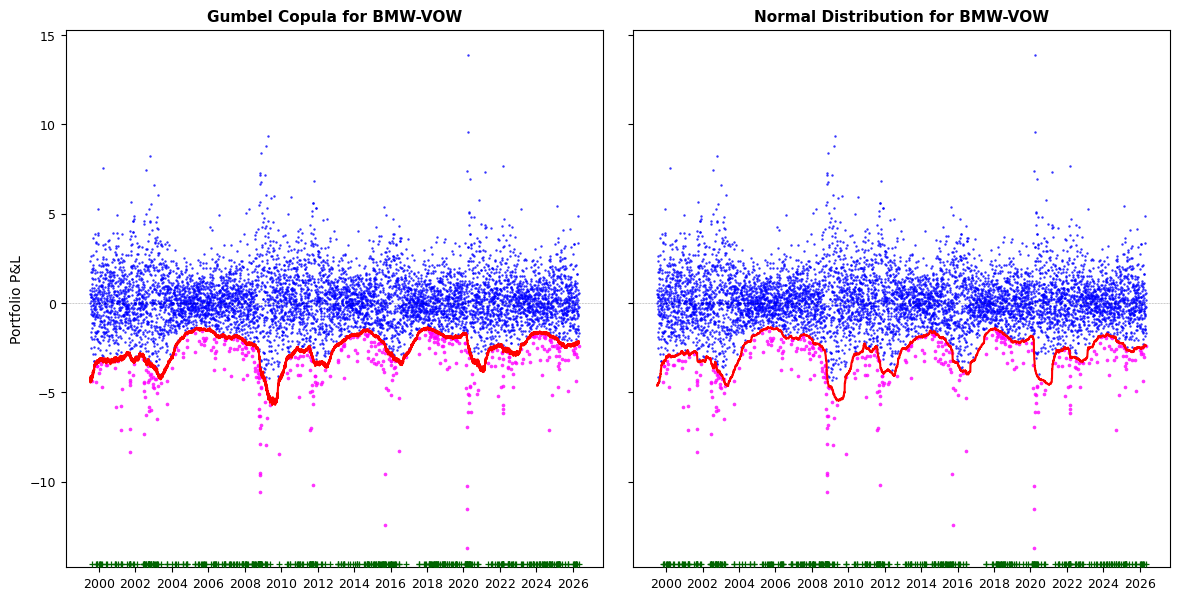

In [13]:
gumbel_series = backtest_var_series(x_bmw, x_vow, dates_bv, copula_params["Gumbel"], "Gumbel",
                                     window=WINDOW, level=LEVEL, n_sim=N_SIM, w=W)
normal_series = backtest_normal_series(x_bmw, x_vow, dates_bv, window=WINDOW, level=LEVEL, w=W)

alpha_gum = float(gumbel_series[3].mean())
alpha_norm = float(normal_series[3].mean())
print(f"\nGumbel alpha_hat = {alpha_gum:.4f}")
print(f"Normal alpha_hat = {alpha_norm:.4f}")

plot_var_panels(
    left_data=gumbel_series, right_data=normal_series,
    left_title="Gumbel Copula for BMW-VOW", right_title="Normal Distribution for BMW-VOW",
    alpha_left=alpha_gum, alpha_right=alpha_norm,
    save_path="fig41_bmw_vow.pdf",
)